✅ Dataset carregado com sucesso!
Formato: (53735, 21)

   vaga_id                                        titulo_vaga  \
0     4530                                CONSULTOR CONTROL M   
1     4530                                CONSULTOR CONTROL M   
2     4531  2021-2607395-PeopleSoft Application Engine-Dom...   
3     4531  2021-2607395-PeopleSoft Application Engine-Dom...   
4     4533  2021-2605708-Microfocus Application Life Cycle...   

                    cliente nivel_vaga nivel_ingles_vaga nivel_espanhol_vaga  \
0  Morris, Moran and Dodson      Pleno             Outro               Outro   
1  Morris, Moran and Dodson      Pleno             Outro               Outro   
2         Gonzalez and Sons     Sênior             Outro               Outro   
3         Gonzalez and Sons     Sênior             Outro               Outro   
4              Barnes-Woods     Sênior             Outro             Fluente   

       local_vaga                                    requisitos_vaga  \
0

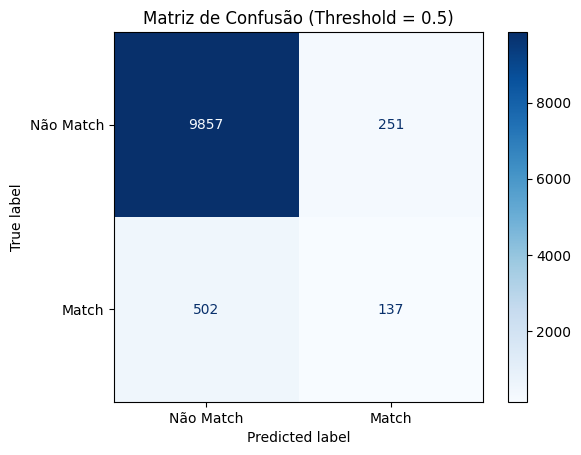

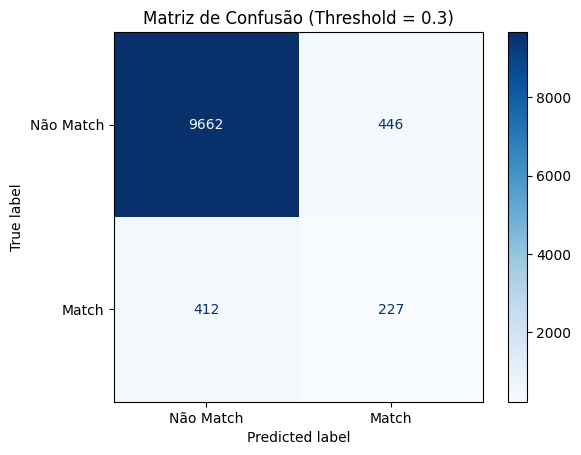

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# 📍 Caminho para o dataset
caminho_dataset = os.path.join("..", "output", "dataset_unificado.csv")

# 📥 Leitura do dataset
df = pd.read_csv(caminho_dataset)
print("✅ Dataset carregado com sucesso!")
print(f"Formato: {df.shape}\n")
print(df.head())

# 🔑 Preencher NaN nos textos
df['requisitos_vaga'] = df['requisitos_vaga'].fillna('')
df['cv_texto'] = df['cv_texto'].fillna('')

# 🎯 Separação entre X e y
if 'match' in df.columns:
    X = df.drop(columns=['match'])
    y = df['match']
else:
    raise ValueError("Coluna 'match' não encontrada.")

# 📊 Verifique desbalanceamento
print("\n📊 Distribuição do target (match):")
print(y.value_counts(normalize=True))

# 🏷️ Features categóricas e texto
cat_cols = [
    'nivel_vaga', 'nivel_ingles_vaga', 'nivel_espanhol_vaga',
    'nivel_academico', 'nivel_ingles', 'cliente', 'local_vaga'
]
num_cols = []  # Adicione colunas numéricas, se houver

# 🛠️ Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

text_pipeline = TfidfVectorizer(max_features=100)

# ⚙️ Column transformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('req_text', text_pipeline, 'requisitos_vaga'),
    ('cv_text', text_pipeline, 'cv_texto')
])

# 🚂 Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print(f"\n🏷️ Classes no treino: {y_train.value_counts().to_dict()}")
print(f"🏷️ Classes no teste: {y_test.value_counts().to_dict()}")

# 🧠 Pipeline com Random Forest balanceado
modelo_rf = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )
)

# 🔧 Treinamento
modelo_rf.fit(X_train, y_train)
print("✅ Modelo treinado com sucesso!")

# 📈 Avaliação padrão (threshold 0.5)
y_pred_default = modelo_rf.predict(X_test)
relatorio_default = classification_report(y_test, y_pred_default, digits=3)
print("\n📊 Relatório padrão (threshold=0.5):")
print(relatorio_default)

# 📈 Avaliação ajustada (threshold 0.3)
y_probs = modelo_rf.predict_proba(X_test)[:, 1]
threshold = 0.3
y_pred_adjusted = (y_probs >= threshold).astype(int)
relatorio_adjusted = classification_report(y_test, y_pred_adjusted, digits=3)
print(f"\n📊 Relatório ajustado (threshold={threshold}):")
print(relatorio_adjusted)

# 💾 Salvando modelo
caminho_modelo = os.path.join("..", "output", "modelo_match_rf.joblib")
joblib.dump(modelo_rf, caminho_modelo)
print(f"\n💾 Modelo salvo em: {caminho_modelo}")

# 💾 Salvando relatórios
output_dir = os.path.join("..", "output")
with open(os.path.join(output_dir, "relatorio_classificacao_default.txt"), "w") as f:
    f.write(relatorio_default)

with open(os.path.join(output_dir, "relatorio_classificacao_ajustado.txt"), "w") as f:
    f.write(relatorio_adjusted)

print("📝 Relatórios salvos no diretório de output.")

# 📊 Matriz de confusão - padrão
cm_default = confusion_matrix(y_test, y_pred_default)
disp_default = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=["Não Match", "Match"])
disp_default.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão (Threshold = 0.5)")
plt.show()

# 📊 Matriz de confusão - ajustado
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
disp_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_adjusted, display_labels=["Não Match", "Match"])
disp_adjusted.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão (Threshold = 0.3)")
plt.show()